# Clean Code

## Código Ruim

In [ ]:
# código ruim

X = 10
Y = 20
Z = X+Y
print(Z)

30


## Código melhorado



In [ ]:
# código melhorado
numero1 = 10
numero2 = 20
soma = numero1 + numero2
print(soma)


30


# Modularização

In [ ]:
# Função em módulo separado

def calcular_soma(a,b):
  return a+b

In [ ]:
# Uso da função

resultado = calcular_soma(10,5)

print(resultado)

15


# Testes

In [ ]:
def soma(a,b):
  return a+b

  # teste simples
  assert soma(2,3) == 5

## Pytest
Pytest é uma ferramenta para criar testes automatizados.


In [ ]:
def test_soma():
  assert soma(2,2) == 4

# Refatorar

### Exemplo 1

In [ ]:
# Antes de refatorar
def calc(a,b):
  return a+b

In [ ]:
# Depois de refatorado
def calcular_soma(numero1, numero2):
  return numero1+numero2

###  Exemplo 2

In [ ]:
# Antes de refatorar
def processar(lista):
  resultado = []
  for i in lista:
    if i > 10:
      resultado.append(i*2)
    return resultado

In [ ]:
# Depois de Fatorar
def processar_numeros(lista):
  return [numero * 2 for numero in lista if numero > 10]

# Performance

## Redução de complexidade

In [ ]:
# código complexo

def processar(lista):
  return [x*2 for x in lista if x > 10]

## Profiling

In [ ]:
import time

inicio = time.time()

for i in range(1000000):
  pass

fim = time.time()

print(fim - inicio)

0.08238673210144043


## Melhorando performance

In [ ]:
# exemplo copm lista
numeros = list(range(1000000))

# forma rápida
soma = sum(numeros)

print(soma)

499999500000


### Exemplo

In [ ]:
def calcular_total_vendas(vendas):
  return sum(vendas)

dados = [100, 200, 300, 450]

resultado = calcular_total_vendas(dados)

print("Total:", resultado)

Total: 1050


# Modelos de Regressão

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

df = pd.read_csv(url)

df.head()



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# Remove todas as linhas com valores nulos (NaN) do DataFrame.
# Isso evita problemas durante o treinamento do modelo.
df = df.dropna()

# Cria o conjunto de variáveis independentes (features).
# Aqui removemos a coluna "median_house_value", pois ela é o alvo (target).
x = df.drop("median_house_value", axis=1)

# Converte variáveis categóricas em variáveis numéricas (dummy variables).
# Exemplo: "ocean_proximity" vira colunas binárias como "ocean_proximity_NEAR BAY".
x = pd.get_dummies(x)

# Define a variável dependente (target) que queremos prever:
# o valor mediano das casas.
y = df["median_house_value"]


In [ ]:
# Divide os dados em conjuntos de treino e teste.
# - x: variáveis independentes (features)
# - y: variável alvo (target)
# - test_size=0.2 → 20% dos dados vão para teste e 80% para treino
# - random_state=42 → garante reprodutibilidade (mesmo resultado em cada execução)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)



# Esse passo é fundamental porque:

# O treino (x_train, y_train) serve para o modelo aprender os padrões.

# O teste (x_test, y_test) serve para avaliar se o modelo generaliza bem para dados novos.

# Assim você documenta diretamente no código o que está acontecendo.


In [ ]:
# Consolidado
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

df = pd.read_csv(url)

df.head()


df = df.dropna()
x = df.drop("median_house_value", axis=1)
x = pd.get_dummies(x)
y = df["median_house_value"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)



# Modelo de Regressão Linear

Fórmula da Regressão Linear
O modelo busca ajustar uma reta da forma:

𝑦 = 𝛽 0 + 𝛽 1 𝑥 + 𝜖

𝑦: variável dependente (target)

𝑥: variável independente (feature)

𝛽0: intercepto (valor de 𝑦 quando 𝑥=0)

𝛽1: coeficiente angular (quanto 𝑦 varia quando 𝑥 aumenta uma unidade)

𝜖: erro ou resíduo

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# Mean Absolute Error (MAE)

## Definição
O **Mean Absolute Error (MAE)** é uma métrica usada para avaliar modelos de regressão.  
Ele mede a média dos erros absolutos entre os valores previstos (\(\hat{y}_i\)) e os valores reais (\(y_i\)).

## Fórmula

\[
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
\]

- \(n\): número de observações  
- \(y_i\): valor real da observação \(i\)  
- \(\hat{y}_i\): valor previsto pelo modelo para a observação \(i\)  
- \(|y_i - \hat{y}_i|\): erro absoluto da previsão  

## Interpretação
- O MAE indica **quanto, em média, as previsões se afastam dos valores reais**.  
- Quanto menor o MAE, melhor o desempenho do modelo.  
- É uma métrica **robusta** porque não eleva os erros ao quadrado (diferente do MSE), sendo menos sensível a outliers.  

## Exemplo em Python
```python
from sklearn.metrics import mean_absolute_error

# Suponha valores reais e previstos
y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]

# Cálculo do MAE
mae = mean_absolute_error(y_true, y_pred)
print("MAE:", mae)


## Residuos de Modelo

In [ ]:
residuos = y_test - y_pred

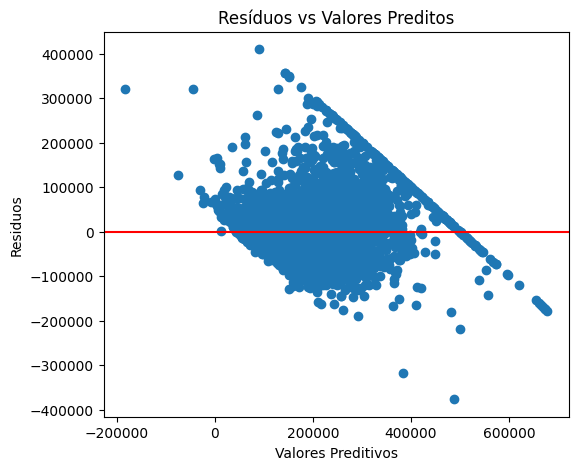

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(y_pred, residuos)

plt.axhline(0, color='red')

plt.xlabel("Valores Preditivos")
plt.ylabel("Residuos")

plt.title("Resíduos vs Valores Preditos")

plt.show()

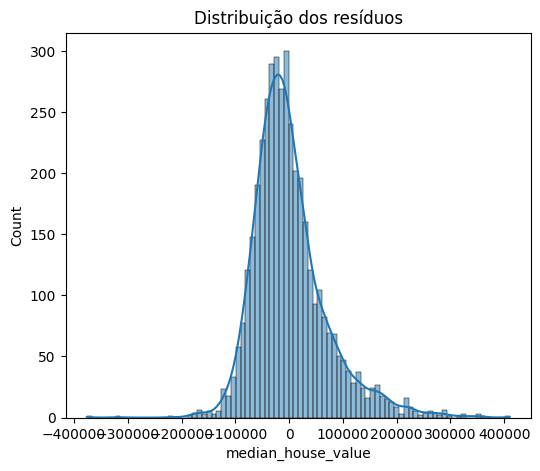

In [ ]:
plt.figure(figsize=(6,5))

sns.histplot(residuos, kde=True)

plt.title("Distribuição dos resíduos")

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

# Calcula o Mean Absolute Error (MAE) entre os valores reais (y_test)
# e os valores previstos pelo modelo (y_pred).
# Fórmula: MAE = (1/n) * Σ |y_i - ŷ_i|
# Interpretação: indica, em média, o quanto as previsões se afastam dos valores reais.
mae = mean_absolute_error(y_test, y_pred)

# Exibe o valor do MAE. Quanto menor, melhor o desempenho do modelo.
mae


50413.43330810045

In [ ]:
from sklearn.metrics import mean_absolute_error

# Suponha valores reais e previstos
y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]

# Cálculo do MAE
mae = mean_absolute_error(y_true, y_pred)
print("MAE:", mae)

MAE: 0.5


# Mean Squared Error (MSE)

## Definição
O **Mean Squared Error (MSE)** é uma métrica usada para avaliar modelos de regressão.  
Ele calcula a média dos erros ao quadrado entre os valores previstos (\(\hat{y}_i\)) e os valores reais (\(y_i\)).

## Fórmula Simplificada
MSE = (1 / n) * Σ (yᵢ - ŷᵢ)²

- n → número de observações  
- yᵢ → valor real da observação i  
- ŷᵢ → valor previsto pelo modelo para a observação i  
- (yᵢ - ŷᵢ)² → erro ao quadrado da previsão

## Interpretação
- O MSE indica **quanto, em média, os erros quadráticos se afastam dos valores reais**.  
- Quanto menor o MSE, melhor o desempenho do modelo.  
- Penaliza mais fortemente erros grandes, pois cada diferença é elevada ao quadrado.  
- É útil quando queremos destacar desvios grandes que não podem ser ignorados.

## Exemplo em Python
```python
from sklearn.metrics import mean_squared_error

# Cálculo do MSE entre valores reais (y_test) e previstos (y_pred)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

mse

4802173538.604137

In [ ]:
from sklearn.metrics import mean_squared_error

# MSE = média dos erros ao quadrado
# Mede o quanto, em média, as previsões se afastam dos valores reais,
# penalizando mais fortemente erros grandes.
mse = mean_squared_error(y_test, y_pred)

mse


# Root Mean Squared Error (RMSE)

## Definição
O **Root Mean Squared Error (RMSE)** é uma métrica usada para avaliar modelos de regressão.  
Ele é a raiz quadrada do **Mean Squared Error (MSE)** e traz o erro médio para a mesma escala dos dados originais.

## Fórmula Simplificada
RMSE = √( (1 / n) * Σ (yᵢ - ŷᵢ)² )

- n → número de observações  
- yᵢ → valor real da observação i  
- ŷᵢ → valor previsto pelo modelo para a observação i  
- (yᵢ - ŷᵢ)² → erro ao quadrado da previsão  

## Interpretação
- O RMSE indica, em média, o tamanho dos erros de previsão na **mesma unidade da variável alvo**.  
- Quanto menor o RMSE, melhor o desempenho do modelo.  
- Por ser derivado do MSE, ainda penaliza erros grandes, mas é mais fácil de interpretar porque está na escala dos dados.

## Exemplo em Python
```python
from sklearn.metrics import mean_squared_error
import numpy as np

# Cálculo do RMSE entre valores reais (y_test) e previstos (y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)


In [ ]:
# O RMSE é simplesmente a raiz quadrada do MSE.
# Isso permite intepretar o erro na mesma unidade da variável resposta.
rmse = np.sqrt(mse)

rmse

np.float64(69297.71669113015)

# Mean Absolute Percentage Error (MAPE)

## Definição
O **Mean Absolute Percentage Error (MAPE)** é uma métrica usada para avaliar modelos de regressão.  
Ele mede o erro absoluto médio em termos percentuais, ou seja, mostra em média **quanto o modelo erra em relação ao valor real**.

## Fórmula Simplificada
MAPE = (100 / n) * Σ ( |yᵢ - ŷᵢ| / |yᵢ| )

- n → número de observações  
- yᵢ → valor real da observação i  
- ŷᵢ → valor previsto pelo modelo para a observação i  
- |yᵢ - ŷᵢ| → erro absoluto da previsão  
- |yᵢ| → valor real usado como referência para calcular a porcentagem  

## Interpretação
- O MAPE indica o erro médio percentual das previsões.  
- Exemplo: MAPE = 8 → significa que, em média, o modelo erra **8%** em relação ao valor real.  
- Quanto menor o MAPE, melhor o desempenho do modelo.  
- Atenção: se algum valor real \(yᵢ\) for zero, o MAPE pode ficar indefinido ou distorcido.

## Exemplo em Python
```python
import numpy as np

# Valores reais e previstos
y_true = np.array([100, 200, 300, 400])
y_pred = np.array([110, 190, 290, 410])

# Cálculo do MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print("MAPE:", mape)

In [ ]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

mape

np.float64(28.5959744711941)

# Coeficiente de Determinação (R²)

## Definição
O **Coeficiente de Determinação (R²)** é uma métrica usada para avaliar modelos de regressão.  
Ele indica a proporção da variabilidade dos dados que é explicada pelo modelo.

## Fórmula Simplificada
R² = 1 - (SS_res / SS_tot)

- **SS_res** → soma dos quadrados dos resíduos: Σ (yᵢ - ŷᵢ)²  
- **SS_tot** → soma dos quadrados totais: Σ (yᵢ - ȳ)²  
- yᵢ → valor real da observação i  
- ŷᵢ → valor previsto pelo modelo  
- ȳ → média dos valores reais  

## Interpretação
- R² varia entre **0 e 1** (embora possa ser negativo em alguns casos).  
- **R² = 0** → o modelo não explica nenhuma variabilidade dos dados.  
- **R² = 1** → o modelo explica toda a variabilidade dos dados (ajuste perfeito).  
- Valores intermediários mostram o quanto o modelo consegue capturar da variação dos dados.  

## Exemplo em Python
```python
from sklearn.metrics import r2_score

# Cálculo do R² entre valores reais (y_test) e previstos (y_pred)
r2 = r2_score(y_test, y_pred)
print("R²:", r2)


In [1]:

from sklearn.metrics import r2_score

# R² = coeficiente de determinação
# Mede a proporção da variabilidade dos dados explicada pelo modelo.
# Fórmula: R² = 1 - (SS_res / SS_tot)

# Interpretação:
# - R² = 0 → modelo não explica nada
# - R² = 1 → modelo explica toda a variabilidade
# Quanto maior o R², melhor o ajuste do modelo.
r2 = r2_score(y_test, y_pred)

r2


NameError: name 'y_test' is not defined

In [ ]:
# Cria um DataFrame com todas as métricas de avaliação do modelo.
# Cada chave do dicionário vira uma coluna (MAE, MSE, RMSE, MAPE, R2),
# e os valores calculados são organizados em uma única linha.

metrics = pd.DataFrame({
    "MAE":[mae],
    "MSE":[mse],
    "RMSE":[rmse],
    "MAPE":[mape],
    "R2":[r2]
})

metrics